In [ ]:
###Evalución
#Una empresa de logística metropolitana requiere un prototipo inteligente para gestionar el despacho de mercancías
#desde su centro principal hacia diversos puntos de entrega. La red vial presenta restricciones de capacidad y
#condiciones climáticas cambiantes que condicionan la habilitación de las rutas.
#El estudiante debe modelar la topología viciada mediante un grafo dirigido y ponderado, construir un módulo de
#verificación lógica que determine si las condiciones operativas permiten el despacho, y aplicar algoritmos de
#búsqueda en grafos para encontrar el recorrido más eficiente.

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

In [ ]:
#Construya un grafo dirigido ponderado (nx.DiGraph) con un mínimo de 8 a 10 nodos representando: 1 Centro
#Principal (Origen), 2-3 Almacenes Intermedios y 4-5 Puntos de Entrega (Destinos).
#Asigne a cada arista dos atributos obligatorios: peso (distancia en km o tiempo en min) y capacidad_maxima
#(toneladas).
#Genere una visualización del grafo usando matplotlib etiquetando nodos y pesos.
#A B C D E F G H 

In [2]:
grafo=nx.DiGraph()

In [3]:
#A Centro
#F G H D Destinos
#C B E ALmacenes
grafo.add_edges_from([
    ("A", "B", {"weight": 15, "capacidad_maxima": 20}),
    ("A", "C", {"weight": 20, "capacidad_maxima": 25}),
    ("B", "D", {"weight": 10, "capacidad_maxima": 10}),
    ("B", "E", {"weight": 12, "capacidad_maxima": 15}),
    ("C", "F", {"weight": 8,  "capacidad_maxima": 12}),
    ("C", "G", {"weight": 25, "capacidad_maxima": 10}),
    ("E", "H", {"weight": 5,  "capacidad_maxima": 5}),
    ("B", "C", {"weight": 30, "capacidad_maxima": 20})
])

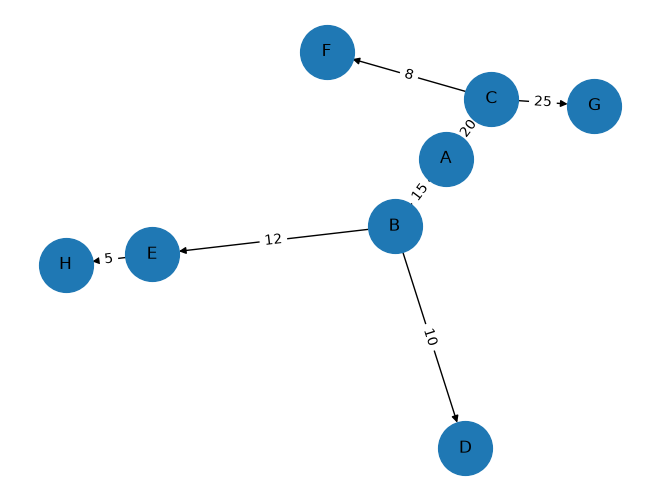

In [4]:
pos = nx.spring_layout(grafo, seed=12)
nx.draw(
    grafo,
    pos,
    with_labels= True,
    node_size=1500,
    arrows=True
)
labels = nx.get_edge_attributes(grafo, "weight")
nx.draw_networkx_edge_labels(
    grafo,
    pos,
    edge_labels=labels
)
plt.show()

In [6]:
print("Verificación de Condiciones")
P = True  # ¿El mantenimiento de los vehículos está al día?
Q = True  # ¿Se respeta el límite de capacidad de carga?
R = True  # ¿Las condiciones climáticas son favorables?

P = input("¿El mantemiento de los vehiculos esta al dia? (s/n): ").lower() =="s"
#Q = input("¿Se respeta el límite de capacidad de carga? (s/n): ").lower() =="s" EL peso se verificara despues 
R = input("¿Las condiciones climáticas son favorables? (s/n): ").lower() =="s"

Verificación de Condiciones


¿El mantemiento de los vehiculos esta al dia? (s/n):  s
¿Las condiciones climáticas son favorables? (s/n):  s


In [9]:
# Solicitamos la carga a transportar
carga_actual = float(input("¿Cuántas toneladas se van a transportar?: "))

origen = "A"
destino = "H"
#[(u, v) for u, v, d in ... if ...]: Es una comprensión de listas en Python. 
#Itera sobre cada arista (donde u es el origen, v el destino y d los atributos)
#y guarda la conexión (u, v) únicamente si se cumple la condición d['capacidad_maxima'] >= carga_actual.
aristas_validas = [(u, v) for u, v, d in grafo.edges(data=True) if d['capacidad_maxima'] >= carga_actual]
#grafo.edges(data=True): Extrae todas las aristas (conexiones) del grafo original. 
#El argumento data=True es clave porque indica que también extraiga los diccionarios de atributos (peso, capacidad máxima) de cada conexión.
grafo_filtrado = grafo.edge_subgraph(aristas_validas) # Crea el subgrafo automáticamente
#grafo.edge_subgraph(aristas_validas): Función de NetworkX que genera un grafo nuevo (subgrafo) utilizando solo la lista de aristas que le proporcionas. 
#Mantiene los atributos originales, pero elimina las rutas descartadas.

¿Cuántas toneladas se van a transportar?:  4


In [14]:
Q = (origen in grafo_filtrado and destino in grafo_filtrado) and nx.has_path(grafo_filtrado, origen, destino)
#nx.has_path(...): Función de NetworkX que analiza el grafo y devuelve un valor booleano (True o False) indicando si 
#es posible llegar desde el nodo origen hasta el nodo destino sin interrupciones.
print(f"Verificación ¿Se respeta capacidad?): {Q}")

# Evaluación final 
S= P and Q and R
if S:
    print("Estado S: True -> Condiciones óptimas. Ruta Autorizada.")
    #nx.shortest_path(...): Ejecuta el algoritmo de Dijkstra en el grafo filtrado para encontrar el camino más eficiente entre los dos nodos.
    ruta = nx.shortest_path(grafo_filtrado, source=origen, target=destino, weight="weight")
    costo = nx.shortest_path_length(grafo_filtrado, source=origen, target=destino, weight="weight")
    
    print(f"Ruta óptima encontrada: {' -> '.join(ruta)}")
    print(f"Costo total de la ruta: {costo} minutos")
else:
    print("Estado S: False -> Condiciones no aptas. Ruta no Autorizada.")
    if P==False:
        print("No se realizo el mantenimiento")
    if Q== False:
        print("Sobrepasa la capacidad de peso por la ruta")
    if R==False: 
        print("Clima no favorable para el envio")

Verificación ¿Se respeta capacidad?): True
Estado S: True -> Condiciones óptimas. Ruta Autorizada.
Ruta óptima encontrada: A -> B -> E -> H
Costo total de la ruta: 32 minutos


In [15]:
Q = (origen in grafo_filtrado and destino in grafo_filtrado) and nx.has_path(grafo_filtrado, origen, destino)
#nx.has_path(...): Función de NetworkX que analiza el grafo y devuelve un valor booleano (True o False) indicando si 
#es posible llegar desde el nodo origen hasta el nodo destino sin interrupciones.
print(f"Verificación ¿Se respeta capacidad?: {Q}")

# Evaluación final 
S = P and Q and R
if S:
    print("Estado S: True -> Condiciones óptimas. Ruta Autorizada.")
    
    # nx.shortest_path(...) sin el parámetro weight ejecuta Búsqueda en Anchura (BFS) 
    # para encontrar el camino con el menor número de saltos.
    ruta_bfs = nx.shortest_path(grafo_filtrado, source=origen, target=destino, weight=None)
    saltos_bfs = nx.shortest_path_length(grafo_filtrado, source=origen, target=destino, weight=None)
    
    # Si aún necesitas calcular el costo en minutos (tiempo/distancia) de esta ruta BFS:
    costo_minutos = sum(grafo_filtrado[u][v].get('weight', 0) for u, v in zip(ruta_bfs[:-1], ruta_bfs[1:]))
    
    print(f"Ruta BFS encontrada (menor cantidad de saltos): {' -> '.join(ruta_bfs)}")
    print(f"Número de saltos (conexiones): {saltos_bfs}")
    print(f"Costo total de la ruta en tiempo: {costo_minutos} minutos")
else:
    print("Estado S: False -> Condiciones no aptas. Ruta no Autorizada.")
    if P == False:
        print("No se realizo el mantenimiento")
    if Q == False:
        print("Sobrepasa la capacidad de peso por la ruta")
    if R == False: 
        print("Clima no favorable para el envio")

Verificación ¿Se respeta capacidad?: True
Estado S: True -> Condiciones óptimas. Ruta Autorizada.
Ruta BFS encontrada (menor cantidad de saltos): A -> B -> E -> H
Número de saltos (conexiones): 3
Costo total de la ruta en tiempo/distancia: 32 minutos
